# Maximum Likelihood Estimation (MLE) in Multilayer Perceptron (MLP)

## Deep Mathematical Background

In a Multilayer Perceptron (MLP), Maximum Likelihood Estimation (MLE) is used to optimize the model parameters (weights and biases) by maximizing the likelihood of the observed data under the model. The MLP is often used for supervised learning tasks, where the goal is to predict a target variable based on input data.

### 1. **Model Setup**
An MLP consists of layers of neurons, where each neuron computes a weighted sum of its inputs, applies an activation function, and passes the result to the next layer. For a dataset $\{(x_i, y_i)\}_{i=1}^{n}$, where $x_i$ are the input features and $y_i$ are the corresponding targets, the MLP defines a mapping:

$$
f(x_i; \theta) = \hat{y}_i
$$

where $\hat{y}_i$ is the predicted output, and $\theta$ represents all the model parameters (weights and biases across all layers).

### 2. **Likelihood Function and Log-Likelihood**
The likelihood function depends on the probability distribution assumed for the target variable $y$ given the input $x$. Let $p(y | x; \theta)$ be the conditional probability of $y$ given $x$ under the model parameters $\theta$.

For MLE, the likelihood of the observed data is:

$$
L(\theta) = \prod_{i=1}^{n} p(y_i | x_i; \theta)
$$

The goal is to find the parameters $\theta$ that maximize this likelihood. In practice, we maximize the log-likelihood, which is easier to work with:

$$
\ell(\theta) = \sum_{i=1}^{n} \log p(y_i | x_i; \theta)
$$

- **Regression**: If we assume the errors are normally distributed with mean $f(x_i; \theta)$ and variance $\sigma^2$, the likelihood function becomes:
  
  $$
  p(y_i | x_i; \theta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - f(x_i; \theta))^2}{2\sigma^2} \right)
  $$
  Maximizing the log-likelihood is equivalent to minimizing the mean squared error (MSE) loss.

- **Classification**: For binary classification with a Bernoulli distribution, the likelihood function is:
  
  $$
  p(y_i | x_i; \theta) = \hat{y}_i^{y_i} (1 - \hat{y}_i)^{1 - y_i}
  $$
  where $\hat{y}_i$ is the output of the sigmoid function. The log-likelihood is the binary cross-entropy loss.

For multiclass classification with a softmax output, the likelihood function becomes the categorical cross-entropy loss.

### 3. **Gradient Descent and Backpropagation**
To find the parameters $\theta$ that maximize the log-likelihood, we use gradient-based optimization methods like stochastic gradient descent (SGD) or Adam. The gradients of the log-likelihood function with respect to the parameters $\theta$ are computed using backpropagation.

Backpropagation calculates the gradients by applying the chain rule, propagating the error from the output layer back through the hidden layers to the input. These gradients are then used to update the parameters $\theta$ in the direction that maximizes the log-likelihood (or equivalently, minimizes the negative log-likelihood, which corresponds to minimizing the loss function).

## PyTorch Implementation

```python
# Install necessary libraries
!pip install torch matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate synthetic data for binary classification
np.random.seed(42)
torch.manual_seed(42)
n_samples = 100
X = np.random.randn(n_samples, 2)  # Input features (2D)
true_w = np.array([3, -2])  # True weights
true_b = 1  # True bias
y = (X @ true_w + true_b > 0).astype(int)  # Binary target variable (0 or 1)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Step 2: Define a simple MLP model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(2, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

model = MLP()

# Step 3: Define the loss function (negative log-likelihood for binary classification)
criterion = nn.BCELoss()  # Binary cross-entropy loss (negative log-likelihood)

# Step 4: Define the optimizer (gradient-based optimization)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Step 5: Training loop
num_epochs = 1000
losses = []

for epoch in range(num_epochs):
    model.train()
    
    # Forward pass
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Step 6: Plot the loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

# Step 7: Evaluate the model
model.eval()
with torch.no_grad():
    predictions = model(X_tensor).round()
    accuracy = (predictions.eq(y_tensor).sum().item()) / n_samples
    print(f'Accuracy: {accuracy * 100:.2f}%')

# Step 8: Visualize decision boundary
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
grid = torch.tensor(np.c_[xx1.ravel(), xx2.ravel()], dtype=torch.float32)
probs = model(grid).reshape(xx1.shape)

plt.contourf(xx1, xx2, probs.detach().numpy(), levels=25, cmap="RdBu", alpha=0.7)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap="RdBu")
plt.show()


In [1]:
!pip install torch==2.0.1 matplotlib==3.7.2

Epoch [100/1000], Loss: 0.0951
Epoch [200/1000], Loss: 0.0604
Epoch [300/1000], Loss: 0.0469
Epoch [400/1000], Loss: 0.0384
Epoch [500/1000], Loss: 0.0323
Epoch [600/1000], Loss: 0.0276
Epoch [700/1000], Loss: 0.0239
Epoch [800/1000], Loss: 0.0208
Epoch [900/1000], Loss: 0.0182
Epoch [1000/1000], Loss: 0.0159


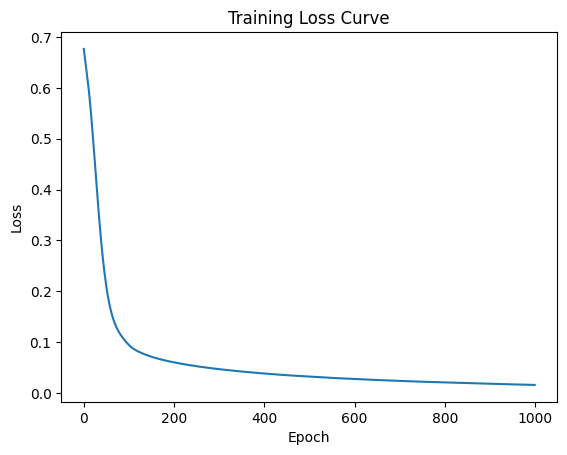

Accuracy: 100.00%


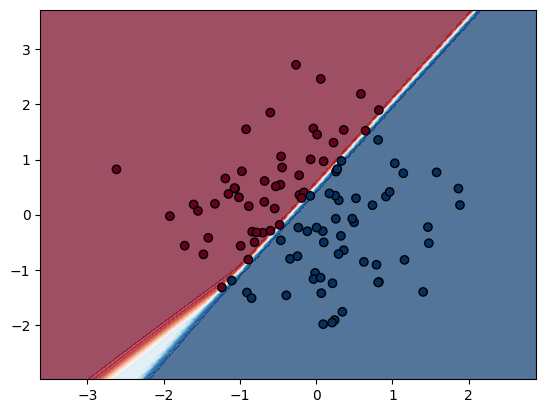

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate synthetic data for binary classification
np.random.seed(42)
torch.manual_seed(42)
n_samples = 100
X = np.random.randn(n_samples, 2)  # Input features (2D)
true_w = np.array([3, -2])  # True weights
true_b = 1  # True bias
y = (X @ true_w + true_b > 0).astype(int)  # Binary target variable (0 or 1)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Step 2: Define a simple MLP model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(2, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

model = MLP()

# Step 3: Define the loss function (negative log-likelihood for binary classification)
criterion = nn.BCELoss()  # Binary cross-entropy loss (negative log-likelihood)

# Step 4: Define the optimizer (gradient-based optimization)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Step 5: Training loop
num_epochs = 1000
losses = []

for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Step 6: Plot the loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

# Step 7: Evaluate the model
model.eval()
with torch.no_grad():
    predictions = model(X_tensor).round()
    accuracy = (predictions.eq(y_tensor).sum().item()) / n_samples
    print(f'Accuracy: {accuracy * 100:.2f}%')

# Step 8: Visualize decision boundary
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
grid = torch.tensor(np.c_[xx1.ravel(), xx2.ravel()], dtype=torch.float32)
probs = model(grid).reshape(xx1.shape)

plt.contourf(xx1, xx2, probs.detach().numpy(), levels=25, cmap="RdBu", alpha=0.7)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap="RdBu")
plt.show()
